# Predicción de Daibetes con Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

In [2]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv'
df = pd.read_csv(url)

print(f'Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas')
df.head()

Dataset cargado: 768 filas y 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# Primero comprobamos si hay valores nulos (vacíos)
print('Valores nulos por columna:')
print(df.isnull().sum())
print()

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



In [6]:
# Ahora revisamos columnas donde un 0 no tiene sentido médico
# Una persona no puede tener glucosa = 0 y estar viva
columnas_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Cantidad de ceros por columna (ceros sospechosos):')
for col in columnas_con_ceros:
    ceros = (df[col] == 0).sum()
    porcentaje = round(ceros / len(df) * 100, 1)
    print(f'  {col}: {ceros} ceros ({porcentaje}%)')

Cantidad de ceros por columna (ceros sospechosos):
  Glucose: 5 ceros (0.7%)
  BloodPressure: 35 ceros (4.6%)
  SkinThickness: 227 ceros (29.6%)
  Insulin: 374 ceros (48.7%)
  BMI: 11 ceros (1.4%)


Conclusión práctica: Insulin y SkinThickness son las variables menos fiables del dataset por la cantidad de datos faltantes.

Glucose, BMI y Age en cambio son las más completas y suelen ser las más útiles para predecir diabetes.

In [7]:
# Reemplazamos los ceros sospechosos por NaN (valor nulo) para tratarlos correctamente
# Esto es solo para las columnas donde 0 no tiene sentido
df[columnas_con_ceros] = df[columnas_con_ceros].replace(0, np.nan)

In [8]:
# Ahora rellenamos esos NaN con la mediana de cada columna
# Usamos la mediana (en lugar de la media) porque es más robusta frente a valores extremos
for col in columnas_con_ceros:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

print('Ceros reemplazados por la mediana de cada columna')
print('Valores nulos restantes:', df.isnull().sum().sum())

Ceros reemplazados por la mediana de cada columna
Valores nulos restantes: 0


Variable Objetivo : OUTCOME ¿Están Equilibrado los datos?

In [9]:
# Contamos cuántos pacientes tienen diabetes (1) y cuántos no (0)
conteo = df['Outcome'].value_counts()

print('Distribución de la variable objetivo (Outcome):')
print(f'  Sin diabetes (0): {conteo[0]} pacientes')
print(f'  Con diabetes (1): {conteo[1]} pacientes')


Distribución de la variable objetivo (Outcome):
  Sin diabetes (0): 500 pacientes
  Con diabetes (1): 268 pacientes


No está perfectamente balanceado pero es aceptable para trabajar con él, es decir, el dataset está moderadamente desbalanceado pero dentro de un rango aceptable, porque la regla general es que un dataset se considera problemático cuando una clase tiene menos del 20% de los datos. Aquí la clase minoritaria tiene el 35%

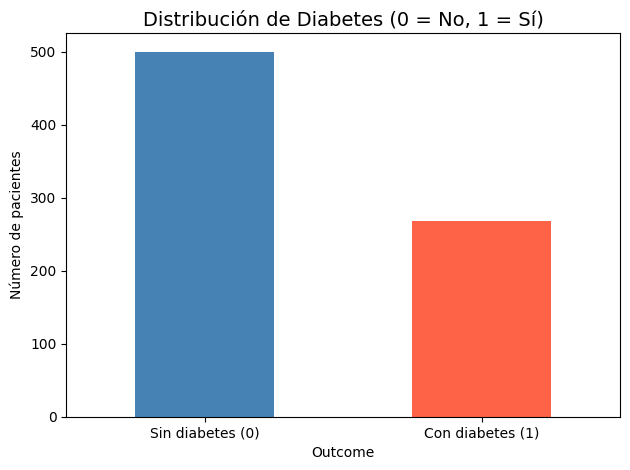

In [10]:
# Gráfica de barras para visualizarlo
fig, ax = plt.subplots()
conteo.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Distribución de Diabetes (0 = No, 1 = Sí)', fontsize=14)
ax.set_xlabel('Outcome')
ax.set_ylabel('Número de pacientes')
ax.set_xticklabels(['Sin diabetes (0)', 'Con diabetes (1)'], rotation=0)
plt.tight_layout()
plt.show()

Correlación entre las Variables

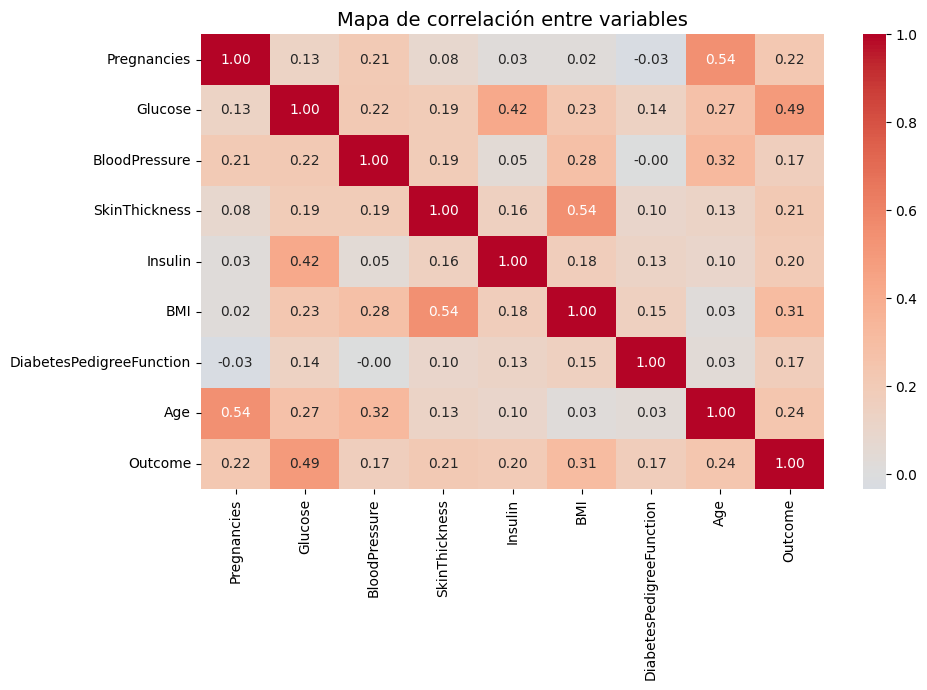

In [11]:
# Mapa de calor de correlaciones
# Los colores más intensos indican mayor correlación
# Paleta de colores: azul (negativo) → rojo (positivo)
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de correlación entre variables', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Confirmamos las *correlaciones* con Outcome, ordenadas de mayor a menor
correlaciones_con_outcome = df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

print('Correlación de cada variable con Outcome (de mayor a menor):')
print(correlaciones_con_outcome.round(3))

Correlación de cada variable con Outcome (de mayor a menor):
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


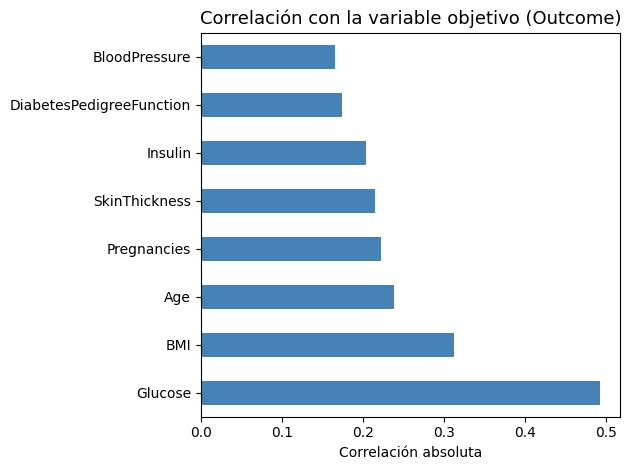

In [13]:
# Gráfica de barras horizontal
correlaciones_con_outcome.plot(kind='barh', color='steelblue')
plt.title('Correlación con la variable objetivo (Outcome)', fontsize=13)
plt.xlabel('Correlación absoluta')
plt.tight_layout()
plt.show()

In [14]:
# X = todas las variables predictoras (lo que el modelo usa para aprender todas menos Outcome)
# y = la variable objetivo (lo que el modelo debe predecir SOLO OUTCOME)
X = df.drop(columns=['Outcome'])  
y = df['Outcome']  

In [15]:
# Dividimos en train (80%) y test (20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Datos divididos correctamente:')
print(f'   Entrenamiento: {X_train.shape[0]} muestras')
print(f'   Prueba:        {X_test.shape[0]} muestras')

Datos divididos correctamente:
   Entrenamiento: 614 muestras
   Prueba:        154 muestras


#Random Forests

In [16]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

In [17]:
# Entrenamos el modelo con los datos de entrenamiento

rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
# Hacemos predicciones sobre los datos de prueba (datos que el modelo no ha visto)
y_pred_base = rf_base.predict(X_test)

In [19]:
# Calculamos la precisión: % de predicciones correctas
acc_base = accuracy_score(y_test, y_pred_base)

print(f'Modelo base entrenado')
print(f'   Accuracy del Random Forest base: {acc_base:.4f} ({acc_base*100:.2f}%)')
print(f'   (Para referencia: el árbol de decisión del proyecto anterior rondaba el 75-78%)')

Modelo base entrenado
   Accuracy del Random Forest base: 0.7792 (77.92%)
   (Para referencia: el árbol de decisión del proyecto anterior rondaba el 75-78%)


#Los dos Hiperparámetros más importantes del Random Forests

In [20]:
# Probamos distintos valores de n_estimators y medimos la precisión en cada caso
valores_n_estimators = [5, 10, 20, 50, 100, 200, 300, 500]

acc_train_n = []  
acc_test_n  = []

for n in valores_n_estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    acc_train_n.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_n.append(accuracy_score(y_test, rf.predict(X_test)))

In [21]:
# Mostramos los resultados en una tabla
df_n = pd.DataFrame({'n_estimators': valores_n_estimators,'Accuracy Train': [round(a, 4) for a in acc_train_n],
    'Accuracy Test':  [round(a, 4) for a in acc_test_n]})
print(df_n.to_string(index=False))

 n_estimators  Accuracy Train  Accuracy Test
            5          0.9658         0.7403
           10          0.9756         0.7727
           20          0.9951         0.7597
           50          1.0000         0.7468
          100          1.0000         0.7792
          200          1.0000         0.7403
          300          1.0000         0.7338
          500          1.0000         0.7338


A partir de 50 árboles el Train llega al 100%, lo que significa que el modelo memoriza perfectamente los datos de entrenamiento. Esto es sobreajuste (overfitting).

El Test no mejora igual que el Train:

Con 5 árboles: 74% en test
Con 100 árboles: 77.92% en test --> mejor resultado
Con 200 árboles: baja a 74%
Con 500 árboles: baja a 73.38%

el punto óptimo son 100 árboles

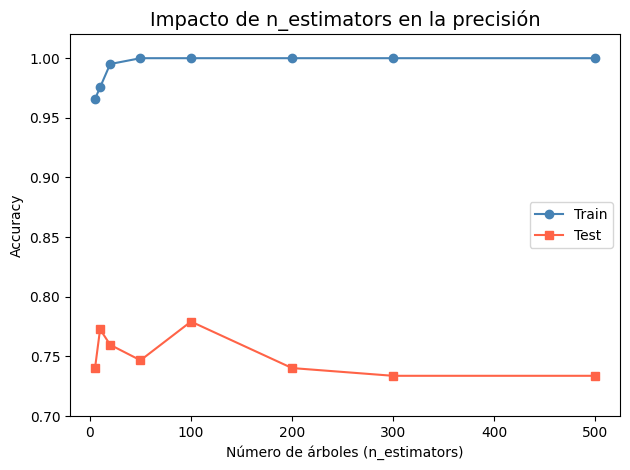

In [22]:
# Gráfica: cómo evoluciona la precisión al aumentar el número de árboles
plt.plot(valores_n_estimators, acc_train_n, marker='o', label='Train', color='steelblue')
plt.plot(valores_n_estimators, acc_test_n,  marker='s', label='Test',  color='tomato')

plt.title('Impacto de n_estimators en la precisión', fontsize=14)
plt.xlabel('Número de árboles (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.7, 1.02)
plt.tight_layout()
plt.show()


In [23]:
#Vemos ahora el impacto de la profundidad máxima (max_depth)
#Y usaremos 100 arboles que fue el valor que nos dió antes en n_estimators

valores_max_depth = [2, 3, 4, 5, 6, 8, 10, None]

acc_train_d = []  
acc_test_d  = []

for d in valores_max_depth:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    
    acc_train_d.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_d.append(accuracy_score(y_test,  rf.predict(X_test)))

In [24]:
# Etiquetas para el eje X 
etiquetas = [str(d) if d is not None else 'Sin límite' for d in valores_max_depth]

In [25]:
# Tabla de resultados
df_d = pd.DataFrame({'max_depth': etiquetas,'Accuracy Train': [round(a, 4) for a in acc_train_d],
    'Accuracy Test':  [round(a, 4) for a in acc_test_d]})
print(df_d.to_string(index=False))

 max_depth  Accuracy Train  Accuracy Test
         2          0.7785         0.7338
         3          0.7932         0.7273
         4          0.8274         0.7208
         5          0.8485         0.7403
         6          0.8844         0.7403
         8          0.9511         0.7403
        10          0.9902         0.7532
Sin límite          1.0000         0.7792



El mejor resultado en Test es Sin límite con 77.92%, pero con Train al 100%. Esto significa que aunque hay sobreajuste, en este dataset particular los árboles sin límite capturan patrones útiles.

La mejor combinación según los datos sería 100 árboles sin límite de profundidad, que es lo que el mapa de calor confirmará también.

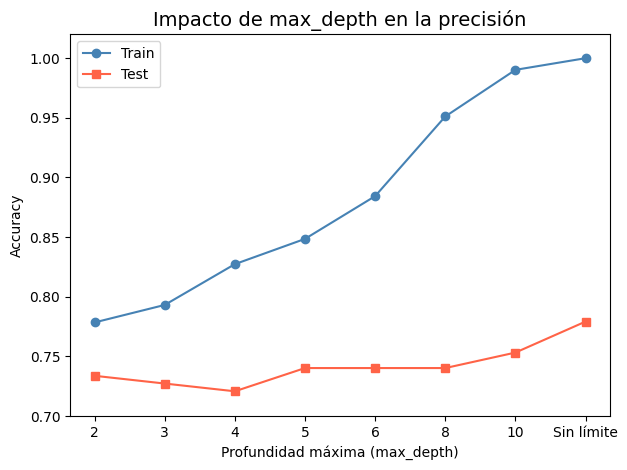

In [26]:
# Gráfica: cómo evoluciona la precisión al cambiar la profundidad
x = range(len(etiquetas)) 

plt.plot(x, acc_train_d, marker='o', label='Train', color='steelblue')
plt.plot(x, acc_test_d,  marker='s', label='Test',  color='tomato')

plt.title('Impacto de max_depth en la precisión', fontsize=14)
plt.xlabel('Profundidad máxima (max_depth)')
plt.ylabel('Accuracy')
plt.xticks(x, etiquetas)  
plt.legend()
plt.ylim(0.7, 1.02)
plt.tight_layout()
plt.show()

#Entrenamiento del modelo final con los mejores Hiperparámetros

In [28]:
modelo_final = RandomForestClassifier(n_estimators=100, max_depth= None, random_state=42)
modelo_final.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
y_pred_final = modelo_final.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_final)

print(f'Accuracy del modelo base:  {acc_base:.4f} ({acc_base*100:.2f}%)')
print(f'Accuracy del modelo final: {acc_final:.4f} ({acc_final*100:.2f}%)')
print(classification_report(y_test, y_pred_final, target_names=['Sin diabetes', 'Con diabetes']))

Accuracy del modelo base:  0.7792 (77.92%)
Accuracy del modelo final: 0.7792 (77.92%)
              precision    recall  f1-score   support

Sin diabetes       0.80      0.88      0.84       100
Con diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



#Guardamos

In [30]:
# Creamos la carpeta 'models' si no existe
os.makedirs('models', exist_ok=True)

# Guardamos el modelo en un archivo .pkl
ruta_modelo = 'models/random_forest_diabetes.pkl'
joblib.dump(modelo_final, ruta_modelo)

['models/random_forest_diabetes.pkl']